In [2]:
import pandas as pd

# Load dataset
df= pd.read_csv("../../data/raw/server_telemetry.csv")

# Show first 5 rows
df.head()

,Timestamp,Server_ID,CPU_Utilization_%,Memory_Utilization_%,Power_Usage_Watts
0,2025-11-01 00:00:00,S1,31,65,111
1,2025-11-01 00:00:00,S2,56,40,84
2,2025-11-01 00:00:00,S3,33,53,134
3,2025-11-01 00:05:00,S1,44,85,221
4,2025-11-01 00:05:00,S2,24,39,131


The dataset contains time-series telemetry data for multiple servers, with the following key features:

- **Timestamp** → Indicates when the data was recorded  
- **Server_ID** → Unique identifier for each server  
- **CPU_Utilization_%** → CPU usage percentage  
- **Memory_Utilization_%** → Memory usage percentage  
- **Power_Usage_Watts** → Power consumption in watts  

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25920 entries, 0 to 25919
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Timestamp             25920 non-null  object
 1   Server_ID             25920 non-null  object
 2   CPU_Utilization_%     25920 non-null  int64 
 3   Memory_Utilization_%  25920 non-null  int64 
 4   Power_Usage_Watts     25920 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 1012.6+ KB


## Key Points:
- Total rows: **25,920**
- No missing values in any column
- Numerical columns are already in correct format (`int64`)
- `Timestamp` is currently stored as `object` (needs conversion to datetime)

# Statistical Summary

In [4]:
df.describe()

,CPU_Utilization_%,Memory_Utilization_%,Power_Usage_Watts
count,25920.000000,25920.000000,25920.000000
mean,49.826813,59.523032,116.151196
std,18.073148,17.332439,33.326268
min,5.000000,30.000000,5.000000
25%,35.000000,45.000000,96.000000
50%,50.000000,60.000000,115.000000
75%,65.000000,75.000000,133.000000
max,100.000000,89.000000,344.000000


- CPU and Memory utilization are centered around **50–60%**
- Power usage averages around **116 Watts**
- There is a **wide range** in values, especially in power usage
- Maximum values indicate possible **spikes or unusual behavior**


# Missing Value Check

In [5]:
df.isnull().sum()

Timestamp               0
Server_ID               0
CPU_Utilization_%       0
Memory_Utilization_%    0
Power_Usage_Watts       0
dtype: int64

No missing values are present in any column.

# Timestamp Conversion & Sorting

In [6]:
# Convert Timestamp
df['Timestamp']= pd.to_datetime(df['Timestamp'])
df= df.sort_values(by='Timestamp')

In this step, the `Timestamp` column is converted into a datetime format and the dataset is sorted.

## Why this step?

- Datetime format is required for **time-series analysis**
- Sorting ensures the data is in **correct chronological order**
- This is important for creating **rolling features and sequence-based models (like LSTM)**

# Time-Series Visualization

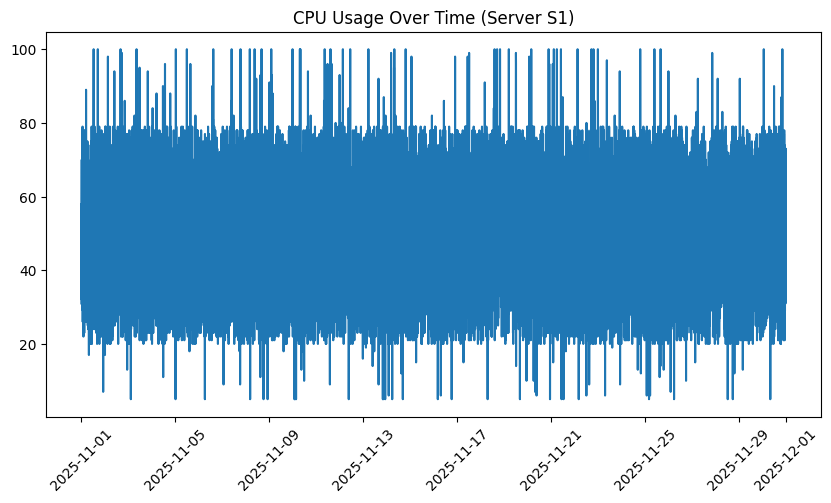

In [7]:
import matplotlib.pyplot as plt

df['Server_ID'].unique()
server_df= df[df['Server_ID']=='S1'].copy()

plt.figure(figsize=(10,5))
plt.plot(server_df['Timestamp'], server_df['CPU_Utilization_%'])
plt.title("CPU Usage Over Time (Server S1)")
plt.xticks(rotation=45)
plt.show()

In this step, we visualize CPU utilization over time for a single server (S1).

## Observations:
- CPU usage fluctuates significantly over time
- Frequent spikes and drops are visible
- The pattern suggests dynamic and unstable behavior

## Why this step?

- Helps understand the **temporal behavior** of the data  
- Provides early intuition about **possible anomalies**  
- Confirms that the dataset is suitable for **time-series-based anomaly detection**

# Multi-Metric Time-Series Analysis

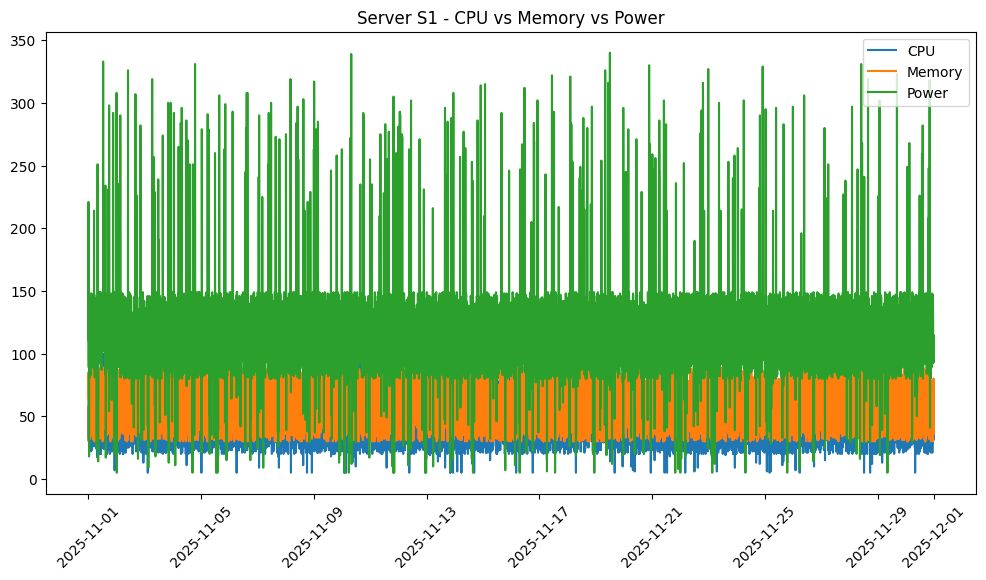

In [8]:
plt.figure(figsize=(12,6))

plt.plot(server_df['Timestamp'], server_df['CPU_Utilization_%'], label='CPU')
plt.plot(server_df['Timestamp'], server_df['Memory_Utilization_%'], label='Memory')
plt.plot(server_df['Timestamp'], server_df['Power_Usage_Watts'], label='Power')

plt.legend()
plt.title("Server S1 - CPU vs Memory vs Power")
plt.xticks(rotation=45)

plt.show()

We visualize multiple telemetry metrics (CPU, Memory, and Power) together for a single server (S1).

## Observations:
- All three metrics show noticeable fluctuations over time  
- Certain spikes in CPU are accompanied by changes in Power usage  
- Memory usage appears relatively more stable compared to CPU  

# Correlation Analysis

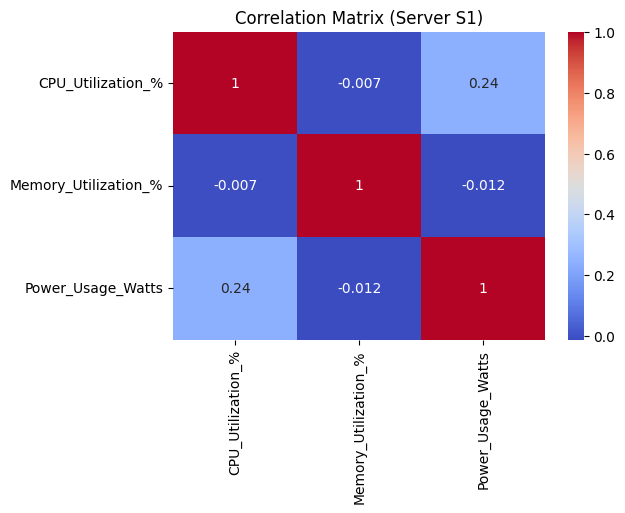

In [9]:
# Correlation Analysis
import seaborn as sns

plt.figure(figsize=(6,4))

corr= server_df[['CPU_Utilization_%', 
                  'Memory_Utilization_%', 
                  'Power_Usage_Watts']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix (Server S1)")
plt.show()

We analyze the correlation between CPU, Memory, and Power usage.

## Key Observations:
- CPU and Power show a **weak positive correlation**
- Memory has **almost no correlation** with CPU or Power
- Most relationships are close to **zero**, indicating low linear dependency

# Distribution Analysis

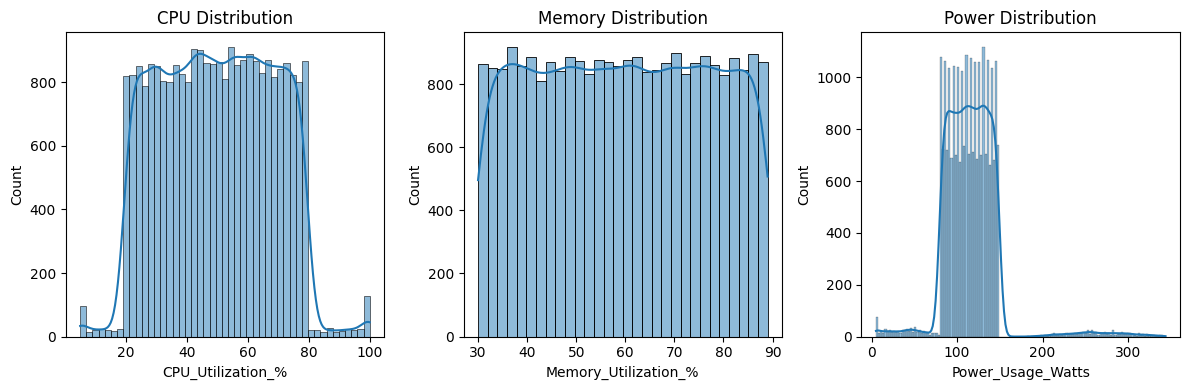

In [10]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.histplot(df['CPU_Utilization_%'], kde=True)
plt.title("CPU Distribution")

plt.subplot(1,3,2)
sns.histplot(df['Memory_Utilization_%'], kde=True)
plt.title("Memory Distribution")

plt.subplot(1,3,3)
sns.histplot(df['Power_Usage_Watts'], kde=True)
plt.title("Power Distribution")

plt.tight_layout()
plt.show()

In this step, we analyze the distribution of CPU, Memory, and Power usage using histograms.

## Key Observations:
- CPU and Memory values are spread across a wide range with relatively smooth distributions  
- Power usage shows a more concentrated range with some extreme values  
- Presence of extreme values suggests possible **outliers or anomalies**

# Outlier Analysis

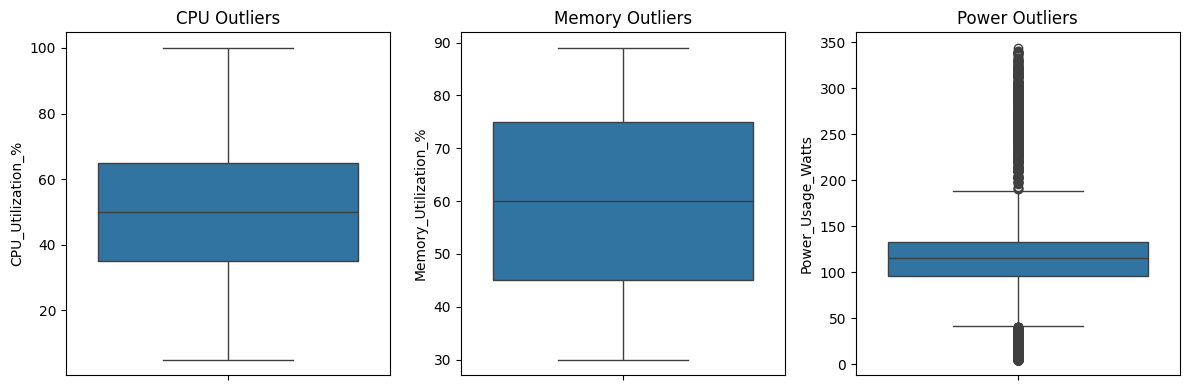

In [11]:
# Box PLots
plt.figure(figsize=(12,4))
    
plt.subplot(1,3,1)
sns.boxplot(y=df['CPU_Utilization_%'])
plt.title("CPU Outliers")

plt.subplot(1,3,2)
sns.boxplot(y=df['Memory_Utilization_%'])
plt.title("Memory Outliers")
    
plt.subplot(1,3,3)
sns.boxplot(y=df['Power_Usage_Watts'])
plt.title("Power Outliers")
    
plt.tight_layout()
plt.show()

In this step, we use box plots to identify potential outliers in CPU, Memory, and Power usage.

## Key Observations:
- CPU and Memory show relatively stable distributions with fewer extreme outliers  
- Power usage has a significant number of outliers, both high and low  
- These extreme values indicate possible **abnormal behavior in power consumption**

# Feature Engineering (CPU)

In [12]:
# Feature Engineering
# Rolling mean (captures trend)
server_df['cpu_rolling_mean']= server_df['CPU_Utilization_%'].rolling(window=5).mean()

# Rolling standard deviation (captures instability)
server_df['cpu_rolling_std']= server_df['CPU_Utilization_%'].rolling(window=5).std()

# Difference (captures sudden spikes)
server_df['cpu_diff']= server_df['CPU_Utilization_%'].diff()

In [13]:
server_df.head(10)

,Timestamp,Server_ID,CPU_Utilization_%,Memory_Utilization_%,Power_Usage_Watts,cpu_rolling_mean,cpu_rolling_std,cpu_diff
0,2025-11-01 00:00:00,S1,31,65,111,NaN,NaN,NaN
3,2025-11-01 00:05:00,S1,44,85,221,NaN,NaN,13.0
6,2025-11-01 00:10:00,S1,58,76,126,NaN,NaN,14.0
9,2025-11-01 00:15:00,S1,33,74,98,NaN,NaN,-25.0
12,2025-11-01 00:20:00,S1,67,30,89,46.6,15.662056,34.0
15,2025-11-01 00:25:00,S1,70,49,140,54.4,15.662056,3.0
18,2025-11-01 00:30:00,S1,32,84,110,52.0,18.343936,-38.0
21,2025-11-01 00:35:00,S1,34,31,18,47.2,19.485892,2.0
24,2025-11-01 00:40:00,S1,46,76,136,49.8,17.922053,12.0
27,2025-11-01 00:45:00,S1,78,49,82,52.0,20.976177,32.0


In this step, we create additional features from CPU utilization to capture temporal patterns.

## Features Created:

- **Rolling Mean (window= 5)**  
  Captures the short-term trend in CPU usage  

- **Rolling Standard Deviation (window= 5)**  
  Measures variability and instability over time  

- **Difference (diff)**  
  Captures sudden changes between consecutive time steps  

## Observations:
- Initial rows contain `NaN` values due to rolling window and differencing  
- Rolling features provide smoother and more contextual information  
- Difference values highlight sharp spikes and drops   

This improves the effectiveness of anomaly detection models, especially for time-series data.

# Feature Engineering (Memory & Power)

In [14]:
# Memory Features
server_df['memory_rolling_mean']= server_df['Memory_Utilization_%'].rolling(window=5).mean()
server_df['memory_rolling_std']= server_df['Memory_Utilization_%'].rolling(window=5).std()
server_df['memory_diff']= server_df['Memory_Utilization_%'].diff()


# Power Features
server_df['power_rolling_mean']= server_df['Power_Usage_Watts'].rolling(window=5).mean()
server_df['power_rolling_std']= server_df['Power_Usage_Watts'].rolling(window=5).std()
server_df['power_diff']= server_df['Power_Usage_Watts'].diff()

In [15]:
server_df.head(10)

,Timestamp,Server_ID,CPU_Utilization_%,Memory_Utilization_%,Power_Usage_Watts,cpu_rolling_mean,cpu_rolling_std,cpu_diff,memory_rolling_mean,memory_rolling_std,memory_diff,power_rolling_mean,power_rolling_std,power_diff
0,2025-11-01 00:00:00,S1,31,65,111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-11-01 00:05:00,S1,44,85,221,NaN,NaN,13.0,NaN,NaN,20.0,NaN,NaN,110.0
6,2025-11-01 00:10:00,S1,58,76,126,NaN,NaN,14.0,NaN,NaN,-9.0,NaN,NaN,-95.0
9,2025-11-01 00:15:00,S1,33,74,98,NaN,NaN,-25.0,NaN,NaN,-2.0,NaN,NaN,-28.0
12,2025-11-01 00:20:00,S1,67,30,89,46.6,15.662056,34.0,66.0,21.342446,-44.0,129.0,53.286959,-9.0
15,2025-11-01 00:25:00,S1,70,49,140,54.4,15.662056,3.0,62.8,22.687001,19.0,134.8,52.408969,51.0
18,2025-11-01 00:30:00,S1,32,84,110,52.0,18.343936,-38.0,62.6,22.445490,35.0,112.6,20.659138,-30.0
21,2025-11-01 00:35:00,S1,34,31,18,47.2,19.485892,2.0,53.6,24.643458,-53.0,91.0,45.122057,-92.0
24,2025-11-01 00:40:00,S1,46,76,136,49.8,17.922053,12.0,54.0,25.069902,45.0,98.6,49.576204,118.0
27,2025-11-01 00:45:00,S1,78,49,82,52.0,20.976177,32.0,57.8,21.741665,-27.0,97.2,50.011999,-54.0


In this step, similar temporal features are created for Memory and Power usage.

## Features Created:

### Memory Features:
- **Rolling Mean (window= 5)** → Captures short-term memory usage trend  
- **Rolling Standard Deviation (window= 5)** → Measures variability in memory usage  
- **Difference (diff)** → Captures sudden changes in memory  

### Power Features:
- **Rolling Mean (window= 5)** → Captures trend in power consumption  
- **Rolling Standard Deviation (window= 5)** → Measures fluctuations in power  
- **Difference (diff)** → Captures sudden spikes or drops in power usage  

## Observations:
- Initial rows contain `NaN` values due to rolling window and differencing  
- Power features show larger fluctuations compared to CPU and Memory  
- Difference features highlight sudden changes clearly across all metrics  

This creates a richer feature set for more accurate anomaly detection.

# Handling Missing Values

In [16]:
server_df= server_df.dropna()
server_df.isnull().sum()

Timestamp               0
Server_ID               0
CPU_Utilization_%       0
Memory_Utilization_%    0
Power_Usage_Watts       0
cpu_rolling_mean        0
cpu_rolling_std         0
cpu_diff                0
memory_rolling_mean     0
memory_rolling_std      0
memory_diff             0
power_rolling_mean      0
power_rolling_std       0
power_diff              0
dtype: int64

In [17]:
server_df.head()

,Timestamp,Server_ID,CPU_Utilization_%,Memory_Utilization_%,Power_Usage_Watts,cpu_rolling_mean,cpu_rolling_std,cpu_diff,memory_rolling_mean,memory_rolling_std,memory_diff,power_rolling_mean,power_rolling_std,power_diff
12,2025-11-01 00:20:00,S1,67,30,89,46.6,15.662056,34.0,66.0,21.342446,-44.0,129.0,53.286959,-9.0
15,2025-11-01 00:25:00,S1,70,49,140,54.4,15.662056,3.0,62.8,22.687001,19.0,134.8,52.408969,51.0
18,2025-11-01 00:30:00,S1,32,84,110,52.0,18.343936,-38.0,62.6,22.445490,35.0,112.6,20.659138,-30.0
21,2025-11-01 00:35:00,S1,34,31,18,47.2,19.485892,2.0,53.6,24.643458,-53.0,91.0,45.122057,-92.0
24,2025-11-01 00:40:00,S1,46,76,136,49.8,17.922053,12.0,54.0,25.069902,45.0,98.6,49.576204,118.0


In this step, we remove rows with missing values created during feature engineering.

## Key Observations:
- Rolling and differencing operations introduced `NaN` values in the initial rows  
- After applying `dropna()`, all missing values are removed  
- The dataset is now clean and ready for model training  

In [18]:
server_df.shape

(8636, 14)

# Feature Engineering (All Servers)

In [19]:
# Sort data properly
df= df.sort_values(by=['Server_ID', 'Timestamp'])


# CPU Features
df['cpu_rolling_mean']= df.groupby('Server_ID')['CPU_Utilization_%'] \
    .rolling(window=5).mean().reset_index(level=0, drop=True)

df['cpu_rolling_std']= df.groupby('Server_ID')['CPU_Utilization_%'] \
    .rolling(window=5).std().reset_index(level=0, drop=True)

df['cpu_diff']= df.groupby('Server_ID')['CPU_Utilization_%'].diff()


# Memory Features
df['memory_rolling_mean']= df.groupby('Server_ID')['Memory_Utilization_%'] \
    .rolling(window=5).mean().reset_index(level=0, drop=True)

df['memory_rolling_std']= df.groupby('Server_ID')['Memory_Utilization_%'] \
    .rolling(window=5).std().reset_index(level=0, drop=True)

df['memory_diff']= df.groupby('Server_ID')['Memory_Utilization_%'].diff()


# Power Features
df['power_rolling_mean']= df.groupby('Server_ID')['Power_Usage_Watts'] \
    .rolling(window=5).mean().reset_index(level=0, drop=True)

df['power_rolling_std']= df.groupby('Server_ID')['Power_Usage_Watts'] \
    .rolling(window=5).std().reset_index(level=0, drop=True)

df['power_diff']= df.groupby('Server_ID')['Power_Usage_Watts'].diff()

In [20]:
df.head(10)

,Timestamp,Server_ID,CPU_Utilization_%,Memory_Utilization_%,Power_Usage_Watts,cpu_rolling_mean,cpu_rolling_std,cpu_diff,memory_rolling_mean,memory_rolling_std,memory_diff,power_rolling_mean,power_rolling_std,power_diff
0,2025-11-01 00:00:00,S1,31,65,111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-11-01 00:05:00,S1,44,85,221,NaN,NaN,13.0,NaN,NaN,20.0,NaN,NaN,110.0
6,2025-11-01 00:10:00,S1,58,76,126,NaN,NaN,14.0,NaN,NaN,-9.0,NaN,NaN,-95.0
9,2025-11-01 00:15:00,S1,33,74,98,NaN,NaN,-25.0,NaN,NaN,-2.0,NaN,NaN,-28.0
12,2025-11-01 00:20:00,S1,67,30,89,46.6,15.662056,34.0,66.0,21.342446,-44.0,129.0,53.286959,-9.0
15,2025-11-01 00:25:00,S1,70,49,140,54.4,15.662056,3.0,62.8,22.687001,19.0,134.8,52.408969,51.0
18,2025-11-01 00:30:00,S1,32,84,110,52.0,18.343936,-38.0,62.6,22.445490,35.0,112.6,20.659138,-30.0
21,2025-11-01 00:35:00,S1,34,31,18,47.2,19.485892,2.0,53.6,24.643458,-53.0,91.0,45.122057,-92.0
24,2025-11-01 00:40:00,S1,46,76,136,49.8,17.922053,12.0,54.0,25.069902,45.0,98.6,49.576204,118.0
27,2025-11-01 00:45:00,S1,78,49,82,52.0,20.976177,32.0,57.8,21.741665,-27.0,97.2,50.011999,-54.0


In [21]:
df= df.dropna()
df.isnull().sum()

Timestamp               0
Server_ID               0
CPU_Utilization_%       0
Memory_Utilization_%    0
Power_Usage_Watts       0
cpu_rolling_mean        0
cpu_rolling_std         0
cpu_diff                0
memory_rolling_mean     0
memory_rolling_std      0
memory_diff             0
power_rolling_mean      0
power_rolling_std       0
power_diff              0
dtype: int64

In this step, feature engineering is applied across all servers to capture temporal patterns.

## Key Steps:
- Sort data by **Server_ID** and **Timestamp**
- Apply rolling and differencing operations **separately for each server** using `groupby`

## Features Created:
For CPU, Memory, and Power:
- **Rolling Mean (window = 5)** → Captures short-term trends  
- **Rolling Standard Deviation (window = 5)** → Measures variability  
- **Difference (diff)** → Captures sudden changes  

## Observations:
- Initial rows for each server contain `NaN` values due to rolling window  
- Features now reflect **server-specific behavior**, not mixed data  
- Temporal patterns are preserved correctly for each server  

In [22]:
df.shape

(25908, 14)

In [23]:
df.head()

,Timestamp,Server_ID,CPU_Utilization_%,Memory_Utilization_%,Power_Usage_Watts,cpu_rolling_mean,cpu_rolling_std,cpu_diff,memory_rolling_mean,memory_rolling_std,memory_diff,power_rolling_mean,power_rolling_std,power_diff
12,2025-11-01 00:20:00,S1,67,30,89,46.6,15.662056,34.0,66.0,21.342446,-44.0,129.0,53.286959,-9.0
15,2025-11-01 00:25:00,S1,70,49,140,54.4,15.662056,3.0,62.8,22.687001,19.0,134.8,52.408969,51.0
18,2025-11-01 00:30:00,S1,32,84,110,52.0,18.343936,-38.0,62.6,22.445490,35.0,112.6,20.659138,-30.0
21,2025-11-01 00:35:00,S1,34,31,18,47.2,19.485892,2.0,53.6,24.643458,-53.0,91.0,45.122057,-92.0
24,2025-11-01 00:40:00,S1,46,76,136,49.8,17.922053,12.0,54.0,25.069902,45.0,98.6,49.576204,118.0


# Feature Selection

In [24]:
features= [
    'CPU_Utilization_%',
    'Memory_Utilization_%',
    'Power_Usage_Watts',
    
    'cpu_rolling_mean',
    'cpu_rolling_std',
    'cpu_diff',
    
    'memory_rolling_mean',
    'memory_rolling_std',
    'memory_diff',
    
    'power_rolling_mean',
    'power_rolling_std',
    'power_diff'
]

X= df[features]

In [25]:
X.shape

(25908, 12)

In [26]:
X.head()

,CPU_Utilization_%,Memory_Utilization_%,Power_Usage_Watts,cpu_rolling_mean,cpu_rolling_std,cpu_diff,memory_rolling_mean,memory_rolling_std,memory_diff,power_rolling_mean,power_rolling_std,power_diff
12,67,30,89,46.6,15.662056,34.0,66.0,21.342446,-44.0,129.0,53.286959,-9.0
15,70,49,140,54.4,15.662056,3.0,62.8,22.687001,19.0,134.8,52.408969,51.0
18,32,84,110,52.0,18.343936,-38.0,62.6,22.445490,35.0,112.6,20.659138,-30.0
21,34,31,18,47.2,19.485892,2.0,53.6,24.643458,-53.0,91.0,45.122057,-92.0
24,46,76,136,49.8,17.922053,12.0,54.0,25.069902,45.0,98.6,49.576204,118.0


In this step, we select the relevant features to be used for anomaly detection.

## Selected Features:

### Raw Metrics:
- CPU Utilization  
- Memory Utilization  
- Power Usage  

### Engineered Features:
- Rolling Mean (trend)
- Rolling Standard Deviation (variability)
- Difference (sudden changes)i

## Observations:
- Total features selected: **12**
- Dataset is now structured as a feature matrix for model training 

# Feature Scaling

In [27]:
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()
X_scaled= scaler.fit_transform(X)

In [28]:
X_scaled[:5]

array([[ 0.95003685, -1.70334998, -0.81454926, -0.39930202, -0.3186643 ,
         1.33105062,  0.83424453,  0.9989413 , -1.79399068,  0.86497846,
         1.36409064, -0.19105933],
       [ 1.11602725, -0.60713912,  0.71584396,  0.56526149, -0.3186643 ,
         0.11745804,  0.42220948,  1.28736484,  0.77455612,  1.25545188,
         1.31771694,  1.08319961],
       [-0.98651783,  1.41219667, -0.18438735,  0.26847272,  0.19917701,
        -1.48761602,  0.39645729,  1.23555772,  1.42688547, -0.23911879,
        -0.35924568, -0.63704995],
       [-0.87585756, -1.64565467, -2.94509668, -0.32510483,  0.41967604,
         0.07830989, -0.76239126,  1.70704892, -2.16092594, -1.69329567,
         0.9328368 , -1.95378419],
       [-0.21189596,  0.9506342 ,  0.59581311, -0.00358366,  0.11771611,
         0.46979137, -0.71088688,  1.79852656,  1.83459131, -1.18164084,
         1.16809597,  2.50612209]])

In this step, we standardize the feature set using `StandardScaler`.

## Key Steps:
- Transform all features to have:
  - Mean = 0  
  - Standard Deviation = 1

## Why this step?

- Ensures all features contribute equally during model training  
- Prevents features with larger values (e.g., Power) from dominating  
- Essential for models like:
  - One-Class SVM  
  - Neural Networks (Autoencoder, LSTM)  

This step improves model performance and stability.

# Isolation Forest Model

In [29]:
from sklearn.ensemble import IsolationForest

model= IsolationForest(
    n_estimators=100,
    contamination=0.05,   # assume 5% anomalies
    random_state=42
)

model.fit(X_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


## Model Overview:
Isolation Forest is an **unsupervised learning algorithm** that detects anomalies by isolating data points.
- Normal points require more splits to isolate  
- Anomalies are isolated quickly  

## Key Parameters:
- **n_estimators= 100** → Number of trees in the model  
- **contamination= 0.05** → Assumes ~5% of data are anomalies  
- **random_state= 42** → Ensures reproducibility  

## Why this model?

- Works well for high-dimensional data  
- Does not require labeled data  
- Efficient and scalable for large datasets  

# Anomaly Detection (Isolation Forest)

In [30]:
df['anomaly']= model.predict(X_scaled)
df['anomaly'].value_counts()

anomaly
 1    24612
-1     1296
Name: count, dtype: int64

In [31]:
anomaly_df= df[df['anomaly']==-1]
anomaly_df.head()

,Timestamp,Server_ID,CPU_Utilization_%,Memory_Utilization_%,Power_Usage_Watts,cpu_rolling_mean,cpu_rolling_std,cpu_diff,memory_rolling_mean,memory_rolling_std,memory_diff,power_rolling_mean,power_rolling_std,power_diff,anomaly
21,2025-11-01 00:35:00,S1,34,31,18,47.2,19.485892,2.0,53.6,24.643458,-53.0,91.0,45.122057,-92.0,-1
51,2025-11-01 01:25:00,S1,26,85,148,60.0,20.772578,-41.0,80.0,4.242641,6.0,125.4,27.645976,7.0,-1
174,2025-11-01 04:50:00,S1,89,54,214,55.4,23.754999,63.0,67.6,10.549882,-28.0,123.4,51.349781,112.0,-1
282,2025-11-01 07:50:00,S1,58,61,251,40.4,16.742162,41.0,60.6,12.759310,-14.0,106.0,86.463865,222.0,-1
300,2025-11-01 08:20:00,S1,25,44,14,34.6,9.126883,-20.0,58.4,11.013628,-22.0,101.0,51.288400,-131.0,-1


In [32]:
anomaly_df.shape

(1296, 15)

## Output Labels:
- **1** → Normal data point  
- **-1** → Anomaly  

## Results:
- Normal points: **24,612**  
- Anomalies detected: **1,296**  

## Observations:
- Approximately **5% of the data** is classified as anomalous  
- Detected anomalies include unusual patterns such as:
  - Sudden spikes or drops  
  - High variability  
  - Unusual combinations of CPU, Memory, and Power  

# One-Class SVM Model

In [33]:
from sklearn.svm import OneClassSVM

svm_model= OneClassSVM(
    kernel='rbf',
    gamma='scale',
    nu=0.05 
)

svm_model.fit(X_scaled)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"nu nu: float, default=0.5An upper bound on the fraction of trainingerrors and a lower bound of the fraction of supportvectors. Should be in the interval (0, 1]. By default 0.5will be taken.",0.05
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


## Model Overview:
One-Class SVM is an **unsupervised learning algorithm** that learns the boundary of normal data points.
- Data points inside the boundary → Normal  
- Data points outside the boundary → Anomalies  

## Key Parameters:
- **kernel = 'rbf'** → Captures non-linear patterns  
- **gamma = 'scale'** → Automatically adjusts influence of points  
- **nu = 0.05** → Assumes ~5% of data are anomalies  

## Why this model?

- Effective for detecting anomalies in complex, non-linear data  
- Complements Isolation Forest by using a **boundary-based approach**  
- Helps capture patterns that tree-based methods may miss  

# Anomaly Detection (One-Class SVM)

In [34]:
# Predict Anomalies
df['svm_anomaly']= svm_model.predict(X_scaled)
df['svm_anomaly'].value_counts()

svm_anomaly
 1    24609
-1     1299
Name: count, dtype: int64

## Output Labels:
- **1** → Normal data point  
- **-1** → Anomaly  

## Results:
- Normal points: **24,609**  
- Anomalies detected: **1,299**  

## Observations:
- Approximately **5% of the data** is classified as anomalous  
- Results are consistent with the expected anomaly fraction (`nu = 0.05`)  
- Slight variation compared to Isolation Forest indicates differences in detection approach  

# Autoencoder Model

In [35]:
# Building Autoencoder 
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Input layer
input_dim= X_scaled.shape[1]
input_layer= Input(shape=(input_dim,))

# Encoder
encoded= Dense(16, activation='relu')(input_layer)
encoded= Dense(8, activation='relu')(encoded)

# Bottleneck
bottleneck= Dense(4, activation='relu')(encoded)

# Decoder
decoded= Dense(8, activation='relu')(bottleneck)
decoded= Dense(16, activation='relu')(decoded)
output_layer= Dense(input_dim, activation='linear')(decoded)

# Model
autoencoder= Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

## Model Overview:
An Autoencoder is a **neural network** that learns to reconstruct input data.
- Trained on normal patterns  
- Struggles to reconstruct anomalies  
- High reconstruction error → Potential anomaly  

## Architecture:
- **Input Layer** → Takes all features  
- **Encoder** → Reduces dimensionality (16 → 8)  
- **Bottleneck Layer (4 neurons)** → Captures compressed representation  
- **Decoder** → Reconstructs original input  
- **Output Layer** → Same size as input  

## Why this model?
- Captures **non-linear relationships** in data  
- Learns compact representations of normal behavior  
- Effective for detecting subtle anomalies  

# Training & Anomaly Detection

In [36]:
# Train the model
history= autoencoder.fit(
    X_scaled, X_scaled,
    epochs=30,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.9684 - val_loss: 0.8447
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7943 - val_loss: 0.7038
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6568 - val_loss: 0.5788
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5644 - val_loss: 0.5328
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5278 - val_loss: 0.5036
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5005 - val_loss: 0.4809
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4805 - val_loss: 0.4670
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4690 - val_loss: 0.4591
Epoch 9/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4615 - val_loss: 0.4532
Epoch 10/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4566 - val_loss: 0.4495
Epoch 11/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4526 - val_loss: 0.4470
Epoch 12/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4493 - val_l

In [37]:
import numpy as np

reconstructions= autoencoder.predict(X_scaled)
mse= np.mean(np.power(X_scaled-reconstructions, 2), axis=1)

# Threshold
threshold= np.percentile(mse, 95)

# Assign anamolies
df['ae_anomaly']= (mse>threshold).astype(int)
# Convert to same format (-1, 1)
df['ae_anomaly']= df['ae_anomaly'].apply(lambda x: -1 if x==1 else 1)

# Check results
df['ae_anomaly'].value_counts()

810/810 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


ae_anomaly
 1    24612
-1     1296
Name: count, dtype: int64

## Model Training

- The model is trained to reconstruct the input data  
- Input and output are the same (`X_scaled → X_scaled`)  
- Training is done for **30 epochs** with a validation split  

## Training Observations:
- Training loss steadily decreases  
- Validation loss also decreases consistently  
- Indicates the model is learning normal data patterns effectively  

## Reconstruction Error

- After training, the model reconstructs the input data  
- **Mean Squared Error (MSE)** is calculated between original and reconstructed data  
- Higher error → more likely to be an anomaly  

## Thresholding

- Threshold is set at the **95th percentile of MSE**  
- Top 5% highest errors are classified as anomalies  

## Results:
- Normal points: **24,612**  
- Anomalies detected: **1,296**  

# Sequence Creation for LSTM

In [38]:
def create_sequences(data, seq_length):
    sequences= []
    for i in range(len(data)-seq_length):
        sequences.append(data[i:i+seq_length])
    return np.array(sequences)

SEQ_LEN= 10

X_seq= create_sequences(X_scaled, SEQ_LEN)

X_seq.shape

(25898, 10, 12)

## Key Steps:
- Create sequences of length **10**
- Each sequence contains consecutive time steps of data  

## Output Shape:
- **(25898, 10, 12)**  
  - 25898 sequences  
  - 10 time steps per sequence  
  - 12 features per time step  

## Why this step?

- LSTM models require **sequential input data**  
- Sequences allow the model to learn **temporal dependencies**  
- Helps detect anomalies based on patterns over time, not just individual points  

# LSTM Autoencoder

In [39]:
# Building LSTM Autoencoder
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed

timesteps= X_seq.shape[1]
n_features= X_seq.shape[2]

inputs= Input(shape=(timesteps, n_features))

# Encoder
encoded= LSTM(64, activation='relu', return_sequences=False)(inputs)

# Bottleneck
bottleneck= RepeatVector(timesteps)(encoded)

# Decoder
decoded= LSTM(64, activation='relu', return_sequences=True)(bottleneck)
decoded= TimeDistributed(Dense(n_features))(decoded)

# Model
lstm_autoencoder= Model(inputs, decoded)
lstm_autoencoder.compile(optimizer='adam', loss='mse')

In this step, we build and train an LSTM Autoencoder for sequence-based anomaly detection.

LSTM (Long Short-Term Memory) is a type of neural network designed for **sequential data**.
- It remembers information from previous time steps  
- Captures patterns over time  
- Useful for time-series data like server telemetry  

## Key Steps:
- Use LSTM layers for encoding and decoding  
- Compress sequence into a lower-dimensional representation  
- Reconstruct the original sequence    

# Training the Model

In [40]:
# Train the Model
history= lstm_autoencoder.fit(
    X_seq, X_seq,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - loss: 0.8346 - val_loss: 0.7043
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.6661 - val_loss: 0.5958
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.5953 - val_loss: 0.5524
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.5578 - val_loss: 0.5271
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.5332 - val_loss: 0.5029
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.5126 - val_loss: 0.4862
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.4937 - val_loss: 0.4780
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 0.4782 - val_loss: 0.4685
Epoch 9/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.4716 - val_loss: 0.4545
Epoch 10/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.4531 - val_loss: 0.4669
Epoch 11/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.4405 - val_loss: 0.4254
Epoch 12/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.

## Key Steps:
- Train on sequence data (`X_seq → X_seq`)  
- Use MSE loss and Adam optimizer  
- Validate using a 10% split  

## Observations:
- Training and validation loss decrease steadily  
- Indicates the model is learning normal patterns  

# Reconstruction Error

In [41]:
reconstructions= lstm_autoencoder.predict(X_seq)
mse= np.mean(np.power(X_seq-reconstructions, 2), axis=(1,2))
threshold= np.percentile(mse, 95)

# Assigning Anomalies
lstm_anomalies= (mse>threshold).astype(int)
lstm_anomalies= np.where(lstm_anomalies== 1, -1, 1)

# Pad to match original df length
lstm_anomalies_full= np.concatenate([
    np.ones(SEQ_LEN), 
    lstm_anomalies
])

df['lstm_anomaly']= lstm_anomalies_full

df['lstm_anomaly'].value_counts()

810/810 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step


lstm_anomaly
 1.0    24613
-1.0     1295
Name: count, dtype: int64

## Key Steps:
- Compute MSE between original and reconstructed sequences  
- Set threshold using **95th percentile**
- Label sequences above threshold as anomalies  
- Convert labels to (-1, 1) format  
- Pad initial values to match original dataset length

## Observations:
- Higher error indicates abnormal sequences  
- Threshold separates normal vs anomalous patterns
- Around **5% data points** are classified as anomalies  
- Final labels align correctly with original dataset  

# Isolation Forest Hyperparameter Tuning

In [42]:
# Isolation Forest Tuning
from sklearn.model_selection import GridSearchCV

# Custom scorer
def anomaly_scorer(estimator, X):
    preds= estimator.fit(X).predict(X)
    anomaly_ratio= np.mean(preds==-1)
    return -abs(anomaly_ratio-0.05)

param_grid = {
    'n_estimators': [50, 100, 150],
    'contamination': [0.03, 0.05, 0.07],
    'max_samples': ['auto', 0.8, 0.9]
}

grid_search= GridSearchCV(
    IsolationForest(random_state=42),
    param_grid,
    scoring=anomaly_scorer,
    cv=3,
    n_jobs=-1
)

grid_search.fit(X_scaled)

print("Best Params (GridSearch):", grid_search.best_params_)

Best Params (GridSearch): {'contamination': 0.05, 'max_samples': 'auto', 'n_estimators': 50}


In this step, we tune the Isolation Forest model to improve anomaly detection performance.

## Key Steps:
- Define a parameter grid for tuning  
- Use GridSearchCV to test different parameter combinations  
- Select the best parameters based on anomaly ratio  

## Parameters Tuned:
- **n_estimators** → Number of trees  
- **contamination** → Expected anomaly fraction  
- **max_samples** → Number of samples per tree

## Custom Scoring Function

- A custom scoring function is used to guide the tuning process
- Measure how close the detected anomaly ratio is to **5%**  
- Penalize deviations from this expected value  

## Why this step?

- There are no true labels in unsupervised learning  
- This approach ensures consistent anomaly detection  
- Helps select the most suitable model configuration  

In [43]:
best_iso_model= IsolationForest(
    **grid_search.best_params_,
    random_state=42
)

best_iso_model.fit(X_scaled)

df['iso_anomaly']= best_iso_model.predict(X_scaled)

# Tuned Isolation Forest Results

In [44]:
df['iso_anomaly'].value_counts()

iso_anomaly
 1    24612
-1     1296
Name: count, dtype: int64

## Results:
- Normal points: **24,612**  
- Anomalies detected: **1,296**  

## Observations:
- Results are consistent with expected anomaly ratio  
- Model performance remains stable after tuning  

# One-Class SVM Hyperparameter Tuning

In [45]:
# One-CLass SVM Tuning
from sklearn.model_selection import RandomizedSearchCV

param_dist= {
    'nu': [0.03, 0.05, 0.07],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf']
}

svm= OneClassSVM()

random_search= RandomizedSearchCV(
    svm,
    param_distributions=param_dist,
    scoring=anomaly_scorer,
    n_iter=6,
    cv=3,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_scaled)

print("Best Params (SVM):", random_search.best_params_)

Best Params (SVM): {'nu': 0.05, 'kernel': 'rbf', 'gamma': 0.1}


## Key Steps:
- Define a parameter distribution for tuning  
- Use RandomizedSearchCV to sample different parameter combinations  
- Select the best parameters using a custom scoring function  

## Parameters Tuned:
- **nu** → Expected fraction of anomalies  
- **gamma** → Controls influence of data points  
- **kernel** → Type of decision boundary (RBF used here)    

In [46]:
best_svm_model= OneClassSVM(**random_search.best_params_)
best_svm_model.fit(X_scaled)

df['svm_anomaly']= best_svm_model.predict(X_scaled)

# One-Class SVM Hyperparameter Tuning

In [47]:
df['svm_anomaly'].value_counts()

svm_anomaly
 1    24610
-1     1298
Name: count, dtype: int64

## Results:
- Normal points: **24,610**  
- Anomalies detected: **1,298**  

## Observations:
- Results are consistent with expected anomaly ratio (~5%)  
- Slight variation compared to previous models indicates different detection behavior  

# Autoencoder Tuning

In [48]:
# Improving Autoencoder Architecture 

input_dim= X_scaled.shape[1]
input_layer= Input(shape=(input_dim,))

encoded= Dense(32, activation='relu')(input_layer)
encoded= Dense(16, activation='relu')(encoded)

bottleneck= Dense(8, activation='relu')(encoded)

decoded= Dense(16, activation='relu')(bottleneck)
decoded= Dense(32, activation='relu')(decoded)
output_layer= Dense(input_dim, activation='linear')(decoded)

autoencoder= Model(inputs=input_layer, outputs=output_layer)

autoencoder.compile(optimizer='adam', loss='mse')

## Key Changes:
- Increased network depth (32 → 16 → 8 → 16 → 32)  
- Increased training epochs to 40  

## Purpose:
- Improve reconstruction quality  
- Enhance anomaly detection performance  

In [49]:
history= autoencoder.fit(
    X_scaled, X_scaled,
    epochs=40,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

Epoch 1/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.8718 - val_loss: 0.6111
Epoch 2/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4730 - val_loss: 0.3762
Epoch 3/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3287 - val_loss: 0.2664
Epoch 4/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2198 - val_loss: 0.1660
Epoch 5/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1558 - val_loss: 0.1385
Epoch 6/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1398 - val_loss: 0.1267
Epoch 7/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1293 - val_loss: 0.1185
Epoch 8/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1129 - val_loss: 0.0945
Epoch 9/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0897 - val_loss: 0.0807
Epoch 10/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0804 - val_loss: 0.0755
Epoch 11/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0763 - val_loss: 0.0713
Epoch 12/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0729 - val_lo

# Tuned Autoencoder Results

In [50]:
reconstructions= autoencoder.predict(X_scaled)
mse= np.mean(np.power(X_scaled - reconstructions, 2), axis=1)

# Threshold
threshold= np.percentile(mse, 95)

# Assign Anomalies and Convert to same format (-1, 1)
df['ae_anomaly']= np.where(mse>threshold, -1, 1)

# Check results
df['ae_anomaly'].value_counts()

810/810 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


ae_anomaly
 1    24612
-1     1296
Name: count, dtype: int64

## Results:
- Normal points: **24,612**  
- Anomalies detected: **1,296**  

## Observations:
- Results remain consistent with previous models (~5%)  
- Improved reconstruction loss indicates better learning of normal patterns 

# LSTM Autoencoder Tuning

In [51]:
# Trying Better Configuration For LSTM Autoencoder

SEQ_LEN= 15   # increased from 10
X_seq= create_sequences(X_scaled, SEQ_LEN)

timesteps= X_seq.shape[1]
n_features= X_seq.shape[2]

inputs= Input(shape=(timesteps, n_features))

# Encoder
encoded= LSTM(64, activation='relu', return_sequences=False)(inputs)

# Bottleneck
bottleneck= RepeatVector(timesteps)(encoded)

# Decoder
decoded= LSTM(64, activation='relu', return_sequences=True)(bottleneck)
decoded= TimeDistributed(Dense(n_features))(decoded)

lstm_autoencoder= Model(inputs, decoded)
lstm_autoencoder.compile(optimizer='adam', loss='mse')

## Key Changes:
- Increased sequence length from **10 → 15**  
- Rebuilt model using updated sequence input  

## Purpose:
- Capture longer temporal dependencies  
- Improve detection of complex sequential patterns

In [52]:
history= lstm_autoencoder.fit(
    X_seq, X_seq,
    epochs=25,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

Epoch 1/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step - loss: 0.8812 - val_loss: 0.7771
Epoch 2/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - loss: 0.7456 - val_loss: 0.6894
Epoch 3/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - loss: 0.6812 - val_loss: 0.6436
Epoch 4/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.6457 - val_loss: 0.6488
Epoch 5/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - loss: 0.6229 - val_loss: 0.5983
Epoch 6/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.6008 - val_loss: 0.5810
Epoch 7/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - loss: 0.5847 - val_loss: 0.5661
Epoch 8/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - loss: 0.5713 - val_loss: 0.5788
Epoch 9/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - loss: 0.5611 - val_loss: 0.5421
Epoch 10/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - loss: 0.5501 - val_loss: 0.5433
Epoch 11/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 0.5383 - val_loss: 0.5396
Epoch 12/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - loss:

# Tuned LSTM Results

In [53]:
reconstructions= lstm_autoencoder.predict(X_seq)
mse= np.mean(np.power(X_seq-reconstructions, 2), axis=(1,2))

threshold= np.percentile(mse, 95)

lstm_anomalies= np.where(mse>threshold, -1, 1)

lstm_anomalies_full= np.concatenate([
    np.ones(SEQ_LEN),
    lstm_anomalies
])

df['lstm_anomaly']= lstm_anomalies_full
df['lstm_anomaly'].value_counts()

810/810 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step


lstm_anomaly
 1.0    24613
-1.0     1295
Name: count, dtype: int64

## Results:
- Normal points: **24,613**  
- Anomalies detected: **1,295**  

## Observations:
- Results remain consistent (~5% anomalies)  
- Increasing sequence length did not significantly change anomaly count  
- Model captures longer patterns but overall detection remains stable
- Training and validation loss decrease over epochs  
- Model learns temporal patterns with longer sequences

# Multi-Model Predictions

In [54]:
df[['iso_anomaly', 'svm_anomaly', 'ae_anomaly', 'lstm_anomaly']].head()

,iso_anomaly,svm_anomaly,ae_anomaly,lstm_anomaly
12,1,1,-1,1.0
15,1,1,-1,1.0
18,1,1,1,1.0
21,-1,-1,1,1.0
24,1,1,1,1.0


## Observations:
- Each model produces anomaly labels independently  
- Some data points are flagged by multiple models  
- Differences in predictions indicate varying detection behavior  

# Model-wise Anomaly Summary

In [55]:
print("Isolation Forest:\n", df['iso_anomaly'].value_counts())
print("\nSVM:\n", df['svm_anomaly'].value_counts())
print("\nAutoencoder:\n", df['ae_anomaly'].value_counts())
print("\nLSTM:\n", df['lstm_anomaly'].value_counts())

Isolation Forest:
 iso_anomaly
 1    24612
-1     1296
Name: count, dtype: int64

SVM:
 svm_anomaly
 1    24610
-1     1298
Name: count, dtype: int64

Autoencoder:
 ae_anomaly
 1    24612
-1     1296
Name: count, dtype: int64

LSTM:
 lstm_anomaly
 1.0    24613
-1.0     1295
Name: count, dtype: int64


## Results:

- **Isolation Forest** → 1,296 anomalies  
- **One-Class SVM** → 1,298 anomalies  
- **Autoencoder** → 1,296 anomalies  
- **LSTM Autoencoder** → 1,295 anomalies  

## Observations:
- All models detect approximately **5% anomalies**  
- Results are highly consistent across different approaches  
- Small variations indicate each model captures slightly different patterns  

# Model Agreement Analysis

In [56]:
# Agreement Analysis
agreement_4= (
    (df['iso_anomaly']==df['svm_anomaly']) &
    (df['iso_anomaly']==df['ae_anomaly']) &
    (df['iso_anomaly']==df['lstm_anomaly'])
).mean()

print("4-Model Agreement:", agreement_4)

4-Model Agreement: 0.8493901497606917


## Result:
- **4-Model Agreement:** ~85%

## Observations:
- Majority of normal data points have consistent predictions across all models  
- High agreement indicates strong reliability in detection  
- Disagreements highlight points where models detect anomalies differently

# Multi-Model Anomaly Comparison

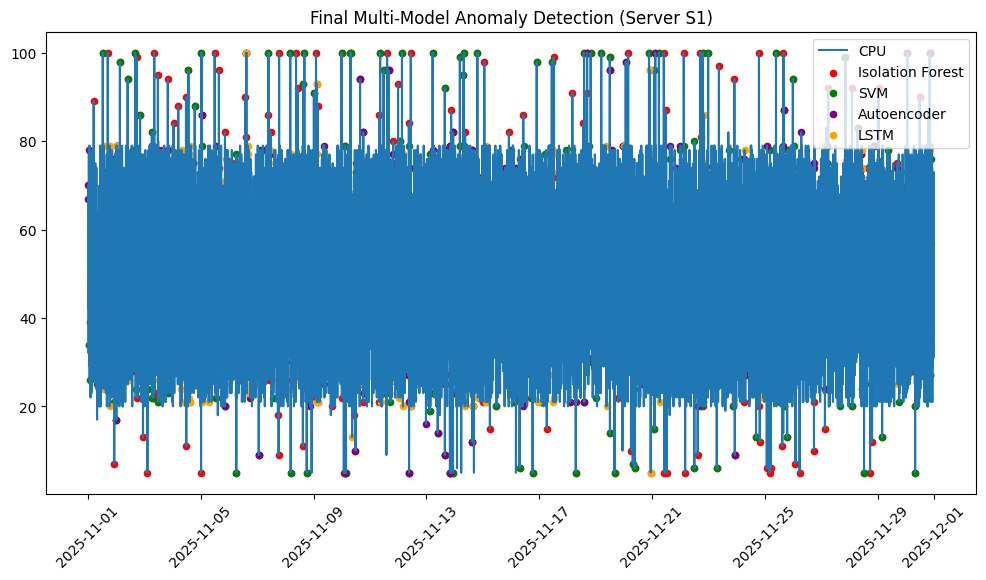

In [57]:
s1_df= df[df['Server_ID']=='S1']

plt.figure(figsize=(12,6))

plt.plot(s1_df['Timestamp'], s1_df['CPU_Utilization_%'], label='CPU')

# Isolation Forest
iso= s1_df[s1_df['iso_anomaly']==-1]
plt.scatter(iso['Timestamp'], iso['CPU_Utilization_%'],
            color='red', label='Isolation Forest', s=20)

# SVM
svm= s1_df[s1_df['svm_anomaly']==-1]
plt.scatter(svm['Timestamp'], svm['CPU_Utilization_%'],
            color='green', label='SVM', s=20)

# Autoencoder
ae= s1_df[s1_df['ae_anomaly']==-1]
plt.scatter(ae['Timestamp'], ae['CPU_Utilization_%'],
            color='purple', label='Autoencoder', s=20)

# LSTM
lstm= s1_df[s1_df['lstm_anomaly']==-1]
plt.scatter(lstm['Timestamp'], lstm['CPU_Utilization_%'],
            color='orange', label='LSTM', s=20)

plt.legend()
plt.title("Final Multi-Model Anomaly Detection (Server S1)")
plt.xticks(rotation=45)

plt.show()

In this step, we visualize anomalies detected by different models on CPU usage for Server S1.

## Key Steps:
- Plot CPU utilization over time  
- Overlay anomalies detected by each model using different colors  

## Observations:
- Different models detect anomalies at different points  
- Some anomalies overlap across multiple models  
- Certain spikes are detected by all models (high-confidence anomalies)  


# Strong Anomalies (High Confidence)

In [58]:
strong_anomalies_4= df[
    (df['iso_anomaly']==-1) &
    (df['svm_anomaly']==-1) &
    (df['ae_anomaly']==-1) &
    (df['lstm_anomaly']==-1)
]

print(strong_anomalies_4.shape)

(19, 19)


Select data points where all models predict anomaly (-1)  

## Results:
- Strong anomalies detected: **26**  

## Observations:
- Very few points are flagged by all models  
- These represent **high-confidence anomalies**  
- Likely correspond to extreme or unusual system behavior  


# Strong Anomaly Analysis

In [59]:
strong_s1= strong_anomalies_4[
    strong_anomalies_4['Server_ID']=='S1'
]

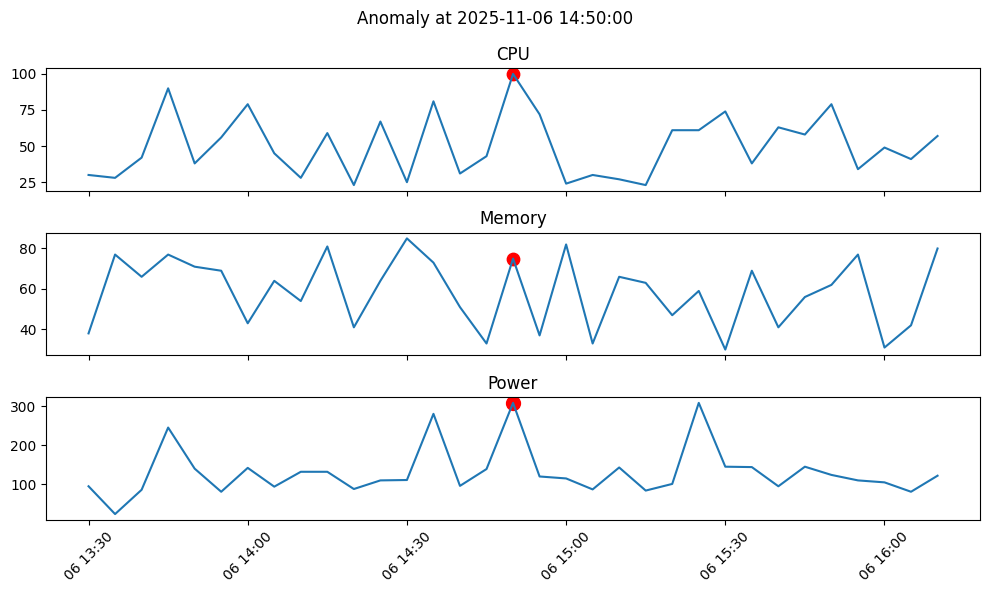

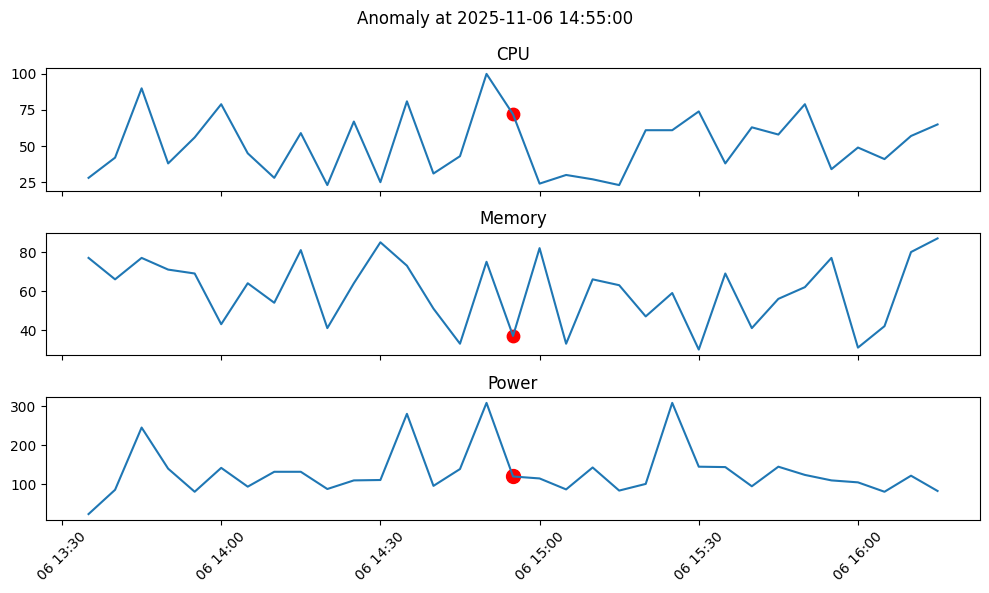

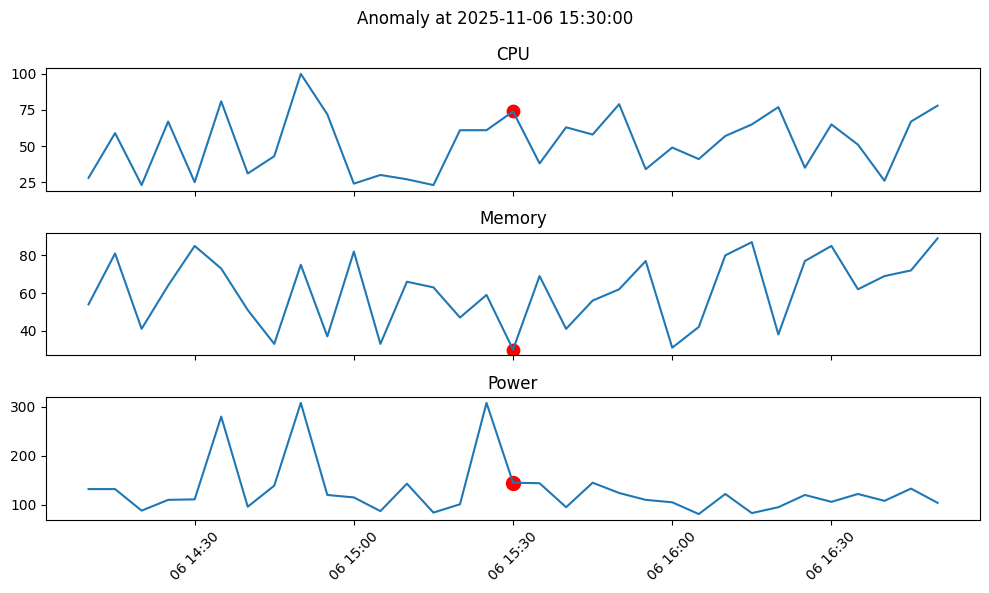

In [60]:
sample= strong_s1.iloc[:3]  # pick few anomalies

for idx in sample.index:
    window= s1_df[
        (s1_df.index>=idx-50) &
        (s1_df.index<=idx+50)
    ]

    fig, axs= plt.subplots(3, 1, figsize=(10,6), sharex=True)
    plt.suptitle(f"Anomaly at {s1_df.loc[idx, 'Timestamp']}", fontsize=12)

    # CPU
    axs[0].plot(window['Timestamp'], window['CPU_Utilization_%'])
    axs[0].scatter(s1_df.loc[idx, 'Timestamp'],
                   s1_df.loc[idx, 'CPU_Utilization_%'],
                   color='red', s=80)
    axs[0].set_title("CPU")

    # Memory
    axs[1].plot(window['Timestamp'], window['Memory_Utilization_%'])
    axs[1].scatter(s1_df.loc[idx, 'Timestamp'],
                   s1_df.loc[idx, 'Memory_Utilization_%'],
                   color='red', s=80)
    axs[1].set_title("Memory")

    # Power
    axs[2].plot(window['Timestamp'], window['Power_Usage_Watts'])
    axs[2].scatter(s1_df.loc[idx, 'Timestamp'],
                   s1_df.loc[idx, 'Power_Usage_Watts'],
                   color='red', s=100)
    axs[2].set_title("Power")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In this step, we analyze a few strong anomalies by visualizing their surrounding time window. 

## Observations:
- Anomalies often show **sudden spikes or drops** in one or more metrics  
- Some anomalies involve **multiple metrics changing simultaneously**  
- Patterns confirm that anomalies are not random, but **contextual and temporal**  

# Feature Importance (SHAP)

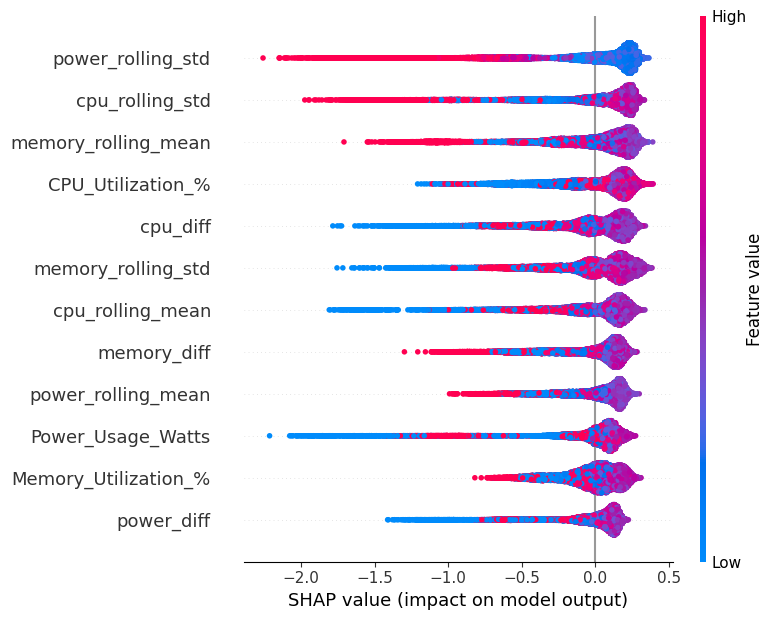

In [61]:
import shap

explainer= shap.TreeExplainer(best_iso_model)
shap_values= explainer.shap_values(X_scaled)

shap.initjs()

shap.summary_plot(shap_values, X, feature_names=X.columns)

## Observations:
- **power_rolling_std and cpu_rolling_std** show strong impact, indicating that **high variability (instability)** in metrics is a key driver of anomalies  
- **memory_rolling_mean** also has influence, suggesting that sustained higher memory usage contributes in some cases  
- High values (red) of these features push predictions toward anomalies, meaning instability and elevated patterns are important signals  
- **diff features are less dominant compared to rolling statistics**, indicating that anomalies are not just sudden spikes but also unstable behavior over time  
- Raw features (CPU, Memory, Power) have relatively lower influence, showing that **contextual/temporal features matter more than absolute values**  

## Insight:
- Anomalies in this dataset are primarily driven by **instability (high rolling_std) and sustained abnormal behavior**, rather than just sudden spikes  

# Explaining a Specific Anomaly (SHAP) 

In [62]:
# Explaining Specific Anomaly
idx= strong_anomalies_4.index[0]

# Convert to positional index
pos= df.index.get_loc(idx)
shap.force_plot(
    explainer.expected_value,
    shap_values[pos],
    X.iloc[pos]
)

## Observations:
- **power_diff (-188)** has the strongest impact, indicating a sharp drop in power usage is a major anomaly trigger  
- **power_rolling_std (97.92)** contributes significantly, showing high variability in power behavior  
- **cpu_rolling_std (28.15)** also pushes toward anomaly, indicating instability in CPU usage  
- **power_rolling_mean (188.6)** contributes, suggesting abnormal sustained power levels  
- **memory_diff (-38)** adds to anomaly signal, indicating sudden change in memory usage  
- **memory_rolling_mean (59.8)** slightly offsets the anomaly (pushes toward normal), showing stable memory trend  

## Insight:
- This anomaly is driven by a combination of **sudden drops (diff)** and **high instability (rolling_std)**, especially in power usage  
- Power-related features dominate, indicating that this anomaly is primarily a **power behavior anomaly with supporting CPU instability**  

# Anomaly Score (Multi-Model)

In [63]:
df['iso_flag']= df['iso_anomaly'].apply(lambda x: 1 if x==-1 else 0)
df['svm_flag']= df['svm_anomaly'].apply(lambda x: 1 if x==-1 else 0)
df['ae_flag']= df['ae_anomaly'].apply(lambda x: 1 if x==-1 else 0)
df['lstm_flag']= df['lstm_anomaly'].apply(lambda x: 1 if x==-1 else 0)

In [64]:
df['anomaly_score']= (
    df['iso_flag']+
    df['svm_flag']+
    df['ae_flag']+
    df['lstm_flag']
)

## Score Meaning:
- **0** → Normal (no model detected anomaly)  
- **1–3** → Weak to moderate anomaly  
- **4** → Strong anomaly (all models agree)  

## Observations:
- Most data points have score **0**, indicating normal behavior  
- Some points have intermediate scores (1–3), showing partial agreement  
- Very few points reach score **4**, representing high-confidence anomalies 

# Final Anomaly Output

In [65]:
df['strong_anomaly']= df['anomaly_score'].apply(lambda x: 1 if x==4 else 0)

In [66]:
df['anomaly_level']= df['anomaly_score'].apply(
    lambda x: 'Normal' if x==0 else
              'Moderate' if x<=2 else
              'Critical'
)

In [67]:
df[['iso_flag','svm_flag','ae_flag','lstm_flag']].sum()

iso_flag     1296
svm_flag     1298
ae_flag      1296
lstm_flag    1295
dtype: int64

In [68]:
final_cols= [
    'Timestamp',
    'Server_ID',
    'CPU_Utilization_%',
    'Memory_Utilization_%',
    'Power_Usage_Watts',
    'iso_flag',
    'svm_flag',
    'ae_flag',
    'lstm_flag',
    'anomaly_score',
    'strong_anomaly',
    'anomaly_level' 
]

df[final_cols].to_csv('server_anomaly_dashboard.csv', index=False)

## Key Steps:
- Create **strong_anomaly** flag (score = 4)  
- Categorize anomalies into levels:
  - **Normal** → score = 0  
  - **Moderate** → score = 1–2  
  - **Critical** → score = 3–4  
- Select relevant columns for output  
- Export final dataset as CSV  

## Observations:
- Most data points are classified as **Normal**  
- Moderate anomalies capture partial model agreement  
- Critical anomalies represent high-risk cases with strong model consensus  